In [1]:
# 2. Data Discovery and Ingestion


In [2]:
#Ingest all sheets with pandas.read_excel().

import pandas as pd
import numpy as np
import os
from datetime import datetime

# Load all CSVs
customers = pd.read_csv("Customers.csv")
models = pd.read_csv("MobileModels.csv")
shops = pd.read_csv("ShopLocations.csv")
sales = pd.read_csv("Sales.csv")
stocks = pd.read_csv("Stocks.csv")
offers = pd.read_csv("Offers.csv")

# Store in a dictionary for easy iteration
datasets = {
    "Customers": customers,
    "MobileModels": models,
    "ShopLocations": shops,
    "Sales": sales,
    "Stocks": stocks,
    "Offers": offers
}

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
#Record metadata: counts, null values, update cycles.

# Function to collect metadata
def get_metadata(df, name):
    return {
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Rows": df.duplicated().sum(),
        "Last Updated": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "File Size (KB)": round(os.path.getsize(f"{name}.csv") / 1024, 2)
    }

# Collect metadata for all
metadata = pd.DataFrame([get_metadata(df, name) for name, df in datasets.items()])

# Display neatly
print("DATASET METADATA SUMMARY:\n")
display(metadata)

DATASET METADATA SUMMARY:



,Dataset,Rows,Columns,Missing Values,Duplicate Rows,Last Updated,File Size (KB)
0,Customers,6000,6,1149,0,2025-11-14 22:50:45,414.22
1,MobileModels,200,6,0,0,2025-11-14 22:50:45,7.17
2,ShopLocations,100,4,0,0,2025-11-14 22:50:45,3.32
3,Sales,40000,10,3964,0,2025-11-14 22:50:45,3059.10
4,Stocks,8000,5,414,0,2025-11-14 22:50:45,328.33
5,Offers,500,7,0,0,2025-11-14 22:50:45,31.70


In [4]:
print("DATA TYPES SUMMARY:\n")

for name, df in datasets.items():
    print(f" {name}")
    print(df.dtypes)
    print("-" * 60)

DATA TYPES SUMMARY:

 Customers
customer_id        object
full_name          object
email              object
phone             float64
city               object
loyalty_points    float64
dtype: object
------------------------------------------------------------
 MobileModels
model_id      object
brand         object
model_name    object
ram_gb         int64
storage_gb     int64
price          int64
dtype: object
------------------------------------------------------------
 ShopLocations
shop_id          object
location         object
manager_name     object
rating          float64
dtype: object
------------------------------------------------------------
 Sales
sale_id          object
customer_id      object
model_id         object
shop_id          object
sale_date        object
quantity          int64
discount        float64
final_price     float64
payment_mode     object
status           object
dtype: object
------------------------------------------------------------
 Stocks
stock_

In [5]:
import shutil

# Create backup folder if not exists
os.makedirs("backup_raw_data", exist_ok=True)

# Copy all files
for name in datasets.keys():
    shutil.copy(f"{name}.csv", f"backup_raw_data/{name}_backup.csv")

print("Backup completed successfully! All raw files saved in 'backup_raw_data/' folder.")

Backup completed successfully! All raw files saved in 'backup_raw_data/' folder.


In [6]:
metadata.to_csv("Data_Metadata_Summary.csv", index=False)
print("Metadata summary saved as 'Data_Metadata_Summary.csv'")

Metadata summary saved as 'Data_Metadata_Summary.csv'


In [7]:
# visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Use a clean visual theme
sns.set(style="whitegrid", palette="viridis", font_scale=1.1)

C:\Users\TANU\AppData\Local\Temp\ipykernel_5804\2903527927.py:8: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\TANU\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


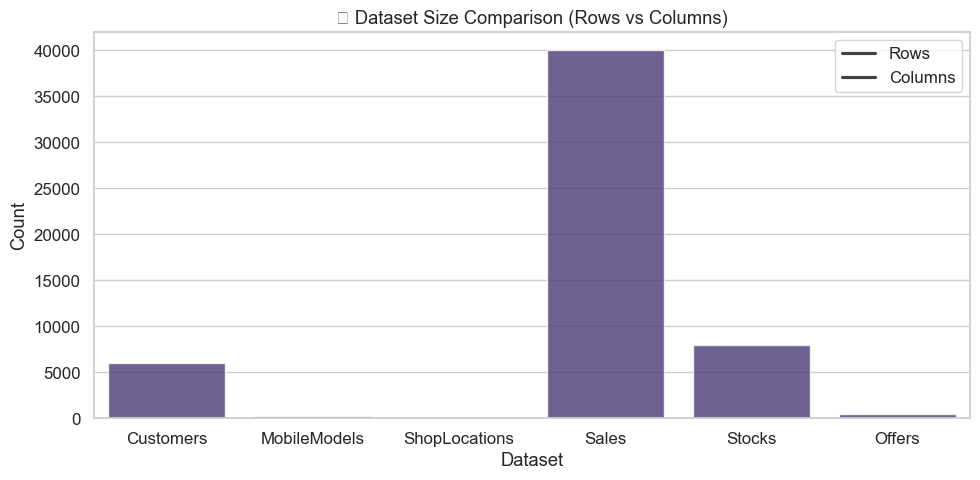

In [8]:
plt.figure(figsize=(10,5))
sns.barplot(x="Dataset", y="Rows", data=metadata, label="Rows", alpha=0.8)
sns.barplot(x="Dataset", y="Columns", data=metadata, color="orange", alpha=0.7)
plt.title("📏 Dataset Size Comparison (Rows vs Columns)")
plt.xlabel("Dataset")
plt.ylabel("Count")
plt.legend(["Rows", "Columns"])
plt.tight_layout()
plt.show()

C:\Users\TANU\AppData\Local\Temp\ipykernel_5804\275289339.py:6: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\TANU\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


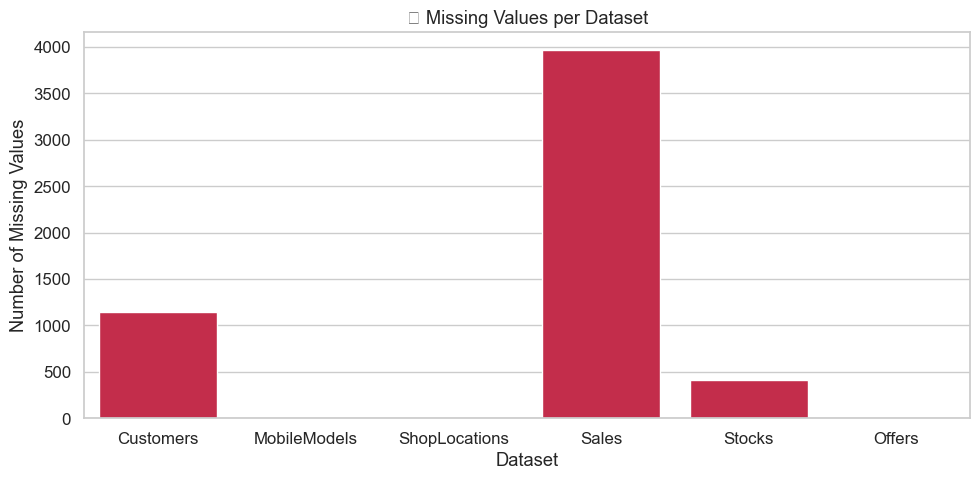

In [9]:
plt.figure(figsize=(10,5))
sns.barplot(x="Dataset", y="Missing Values", data=metadata, color="crimson")
plt.title("🚨 Missing Values per Dataset")
plt.xlabel("Dataset")
plt.ylabel("Number of Missing Values")
plt.tight_layout()
plt.show()

C:\Users\TANU\AppData\Local\Temp\ipykernel_5804\3699222329.py:11: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\TANU\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


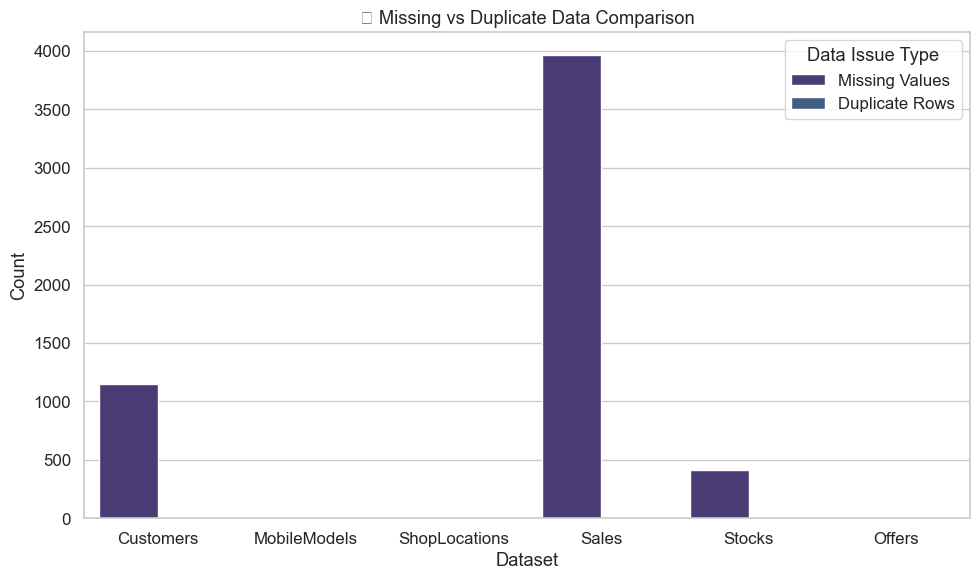

In [10]:
plt.figure(figsize=(10,6))
metadata_melted = metadata.melt(id_vars=["Dataset"], 
                                value_vars=["Missing Values", "Duplicate Rows"],
                                var_name="Metric", value_name="Count")

sns.barplot(x="Dataset", y="Count", hue="Metric", data=metadata_melted)
plt.title("📊 Missing vs Duplicate Data Comparison")
plt.xlabel("Dataset")
plt.ylabel("Count")
plt.legend(title="Data Issue Type")
plt.tight_layout()
plt.show()